In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataframe = pd.read_csv("Zomato-data-.csv")
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [85]:
dataframe.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [3]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [5]:
print(dataframe.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_5192\4253703913.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe['listed_in(type)'],palette='Set2')


Text(0.5, 0, 'Type of restaurant')

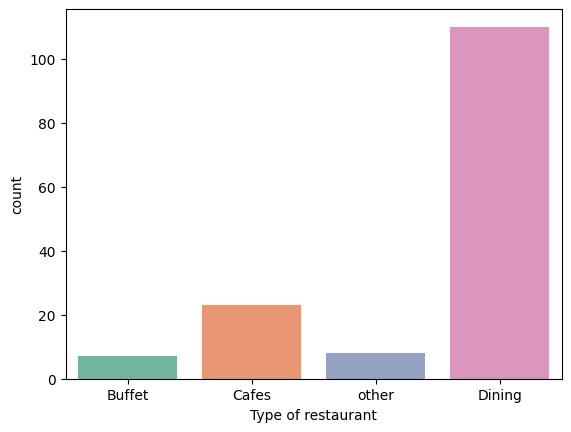

In [7]:
sns.countplot(x=dataframe['listed_in(type)'],palette='Set2')
plt.xlabel("Type of restaurant")

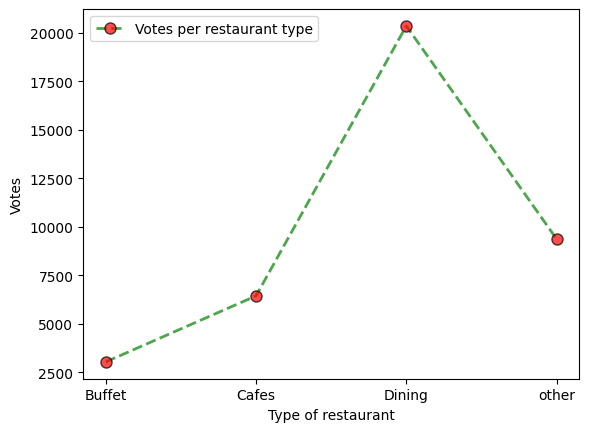

In [12]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o', markersize=8, label='Votes per restaurant type', linewidth=2, markerfacecolor='red', markeredgecolor='black', markeredgewidth=1, linestyle='--', alpha=0.7)
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')
plt.legend()
plt.show()

In [13]:
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


C:\Users\DELL\AppData\Local\Temp\ipykernel_5192\3585846108.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe['online_order'],palette='rainbow')


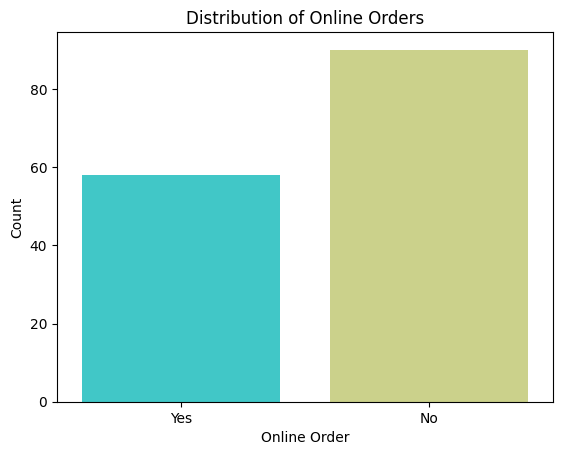

In [14]:
sns.countplot(x=dataframe['online_order'],palette='rainbow')
plt.xlabel("Online Order")
plt.ylabel("Count")
plt.title("Distribution of Online Orders")
plt.show()

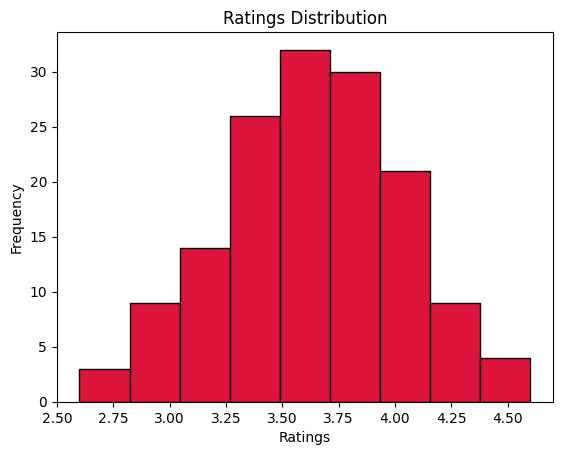

In [26]:
plt.hist(dataframe['rate'],bins=9,color='crimson',edgecolor='black')
plt.title('Ratings Distribution')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_5192\2814501384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=couple_data,palette='Set2')


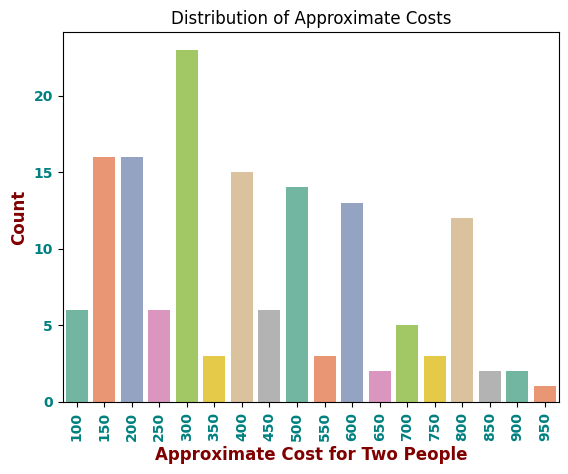

In [41]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data,palette='Set2')
plt.xlabel("Approximate Cost for Two People",fontsize=12,fontweight='bold',color='Maroon')
plt.ylabel("Count",fontsize=12,fontweight='bold',color='Maroon')
plt.xticks(rotation=90,fontsize=10,fontweight='bold',color='teal')
plt.yticks(fontsize=10,fontweight='bold',color='teal')
plt.title("Distribution of Approximate Costs")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_5192\2996585563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


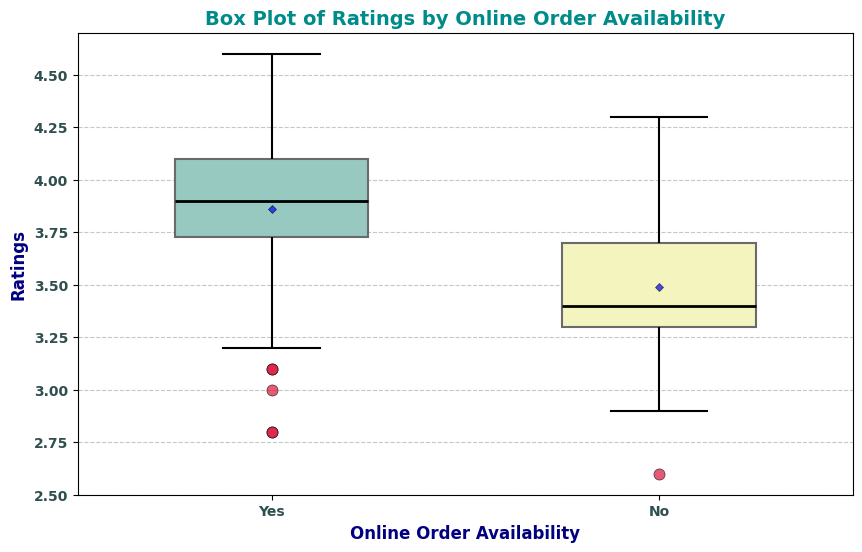

In [64]:
plt.figure(figsize = (10,6))
sns.boxplot(
    x = 'online_order', y = 'rate', 
    data = dataframe, palette = 'Set3',
    width = 0.5, 
    saturation = 0.7, linewidth = 1.5, 
    fliersize = 5, 
    flierprops = {'marker': 'o', 'markersize': 8, 'markerfacecolor': 'crimson', 'markeredgecolor': 'black', 'markeredgewidth': 0.5, 'alpha': 0.7}, 
    medianprops = {'color': 'black', 'linewidth': 2}, whiskerprops = {'color': 'black', 'linewidth': 1.5}, 
    capprops = {'color': 'black', 'linewidth': 1.5},
    showfliers = True, showmeans = True, 
    meanprops = {'marker': 'D', 'markersize': 4, 'markerfacecolor': 'blue', 'markeredgecolor': 'black', 'markeredgewidth': 0.5, 'alpha': 0.7},
    )
plt.title('Box Plot of Ratings by Online Order Availability', fontsize=14, fontweight='bold', color='DarkCyan')
plt.xlabel('Online Order Availability', fontsize=12, fontweight='bold', color='navy')
plt.ylabel('Ratings', fontsize=12, fontweight='bold', color='navy')
plt.xticks(fontsize=10, fontweight='bold', color='DarkSlateGray')
plt.yticks(fontsize=10, fontweight='bold', color='DarkSlateGray')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


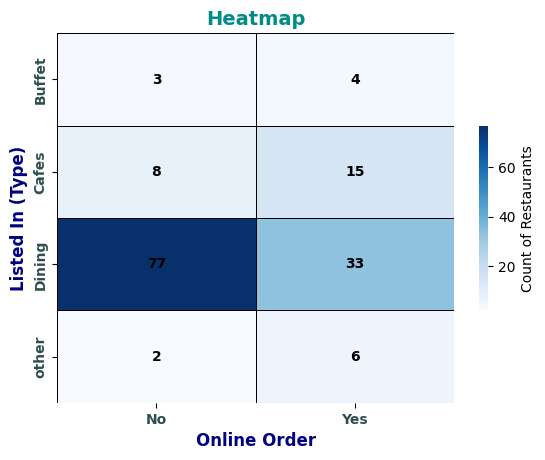

In [84]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='Blues', fmt='d', linewidths=0.5, linecolor='black', 
            cbar_kws={'shrink': 0.5, 'label': 'Count of Restaurants'},
            annot_kws={'fontsize': 10, 'fontweight': 'bold', 'color': 'black'},shading='auto')
plt.title('Heatmap', fontsize=14, fontweight='bold', color='DarkCyan')
plt.xlabel('Online Order', fontsize=12, fontweight='bold', color='navy')
plt.ylabel('Listed In (Type)', fontsize=12, fontweight='bold', color='navy')
plt.xticks(fontsize=10, fontweight='bold', color='DarkSlateGray')
plt.yticks(fontsize=10, fontweight='bold', color='DarkSlateGray')
plt.show()